In [1]:

# imports
# Add cle_fun to PYTHON_PATH
import sys, os, json
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "double"
os.environ["MY_NUMBA_TARGET"] = "cuda"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda


Using double precision
Using C^1
Using CUDA


## Testing sub routines

#### testing step kernel

In [2]:
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

benchmark = {}

num_repeats = 5  # Number of repetitions for statistics
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 5

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs), drift_kernel = gaussian_modified_density_drift_kernel)
    sim = ComplexLangevinSimulation(config)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    # Function to profile
    def get_args():
        sim.cldyn_kernel_bridge.get_current_params()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()

    def update_noise_get():
        sim.update_noise(*sim.cldyn_kernel_args[sim.noise_kernel].values())

    def update_noise():
        sim.update_noise(*sim.cldyn_kernel_args[sim.noise_kernel].values())

    def update_drift(): 
        sim.update_drift(*sim.cldyn_kernel_args[sim.drift_kernel].values())

    def update_field():
        sim.update_field(*sim.cldyn_kernel_args[sim.evolve_kernel].values())

    def swap():
        sim.swap()
        
    def set_apative_stepsize():
        sim.set_apative_stepsize()
    
    def step():
        sim.step()

    functions_to_test = [get_args, update_noise, update_drift, update_field, set_apative_stepsize, swap, step]

    # warmup
    for func in functions_to_test:
        func()

    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 


  0%|          | 0/6 [00:00<?, ?it/s]/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) wi

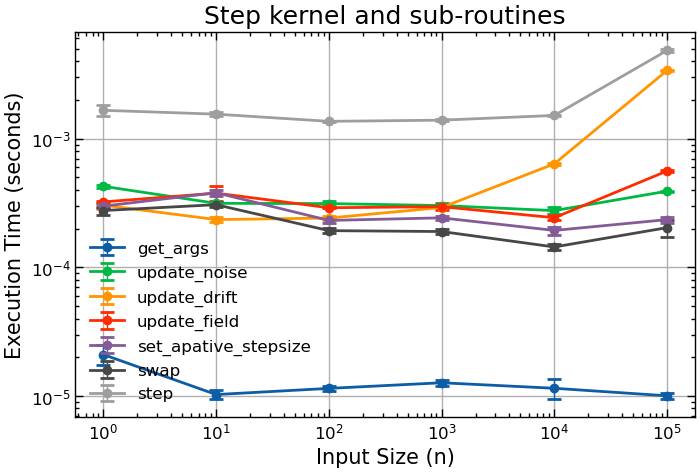

In [3]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

marker kernel

In [4]:
# imports
# Add cle_fun to PYTHON_PATH
import sys, os, json
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "double"
os.environ["MY_NUMBA_TARGET"] = "cuda"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda


In [16]:
np.logspace(0, 20, 20 + 1, base = 2)

array([1.000000e+00, 2.000000e+00, 4.000000e+00, 8.000000e+00,
       1.600000e+01, 3.200000e+01, 6.400000e+01, 1.280000e+02,
       2.560000e+02, 5.120000e+02, 1.024000e+03, 2.048000e+03,
       4.096000e+03, 8.192000e+03, 1.638400e+04, 3.276800e+04,
       6.553600e+04, 1.310720e+05, 2.621440e+05, 5.242880e+05,
       1.048576e+06])

In [ ]:
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

benchmark = {}

num_repeats = 5  # Number of repetitions for statistics3
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 5

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs))
    sim = ComplexLangevinSimulation(config)
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    sim.register_observable('3_moment', obs_kernel=n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()
    
    def kill():
        sim.kill_trajs()

    def mark_eq():
        sim.trackers["1_moment"].mark_equilibrated_trajs()
        sim.trackers["2_moment"].mark_equilibrated_trajs()
        sim.trackers["3_moment"].mark_equilibrated_trajs()

    def compute1():
        sim.trackers["1_moment"].compute()

    def compute2():
        sim.trackers["2_moment"].compute()

    def compute3():
        sim.trackers["3_moment"].compute()


    functions_to_test = [kill, mark_eq, compute1, compute2, compute3]
    
    for func in functions_to_test: 
        func()
    
    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 


  0%|          | 0/6 [00:00<?, ?it/s]

/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numba/cuda/compiler.py:726: NumbaPerformanceWarning: Grid size (1) < 2 * SM count (6) will likely result in GPU under utiliza

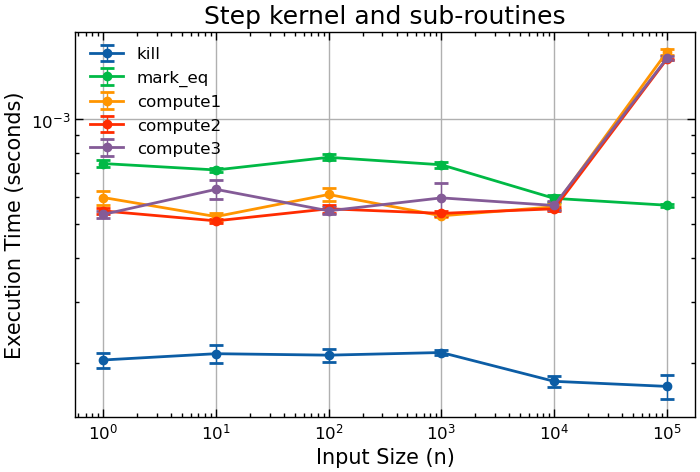

In [6]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

In [9]:
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

benchmark = {}

num_repeats = 5  # Number of repetitions for statistics
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 6

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs))
    sim = ComplexLangevinSimulation(config)
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    sim.register_observable('3_moment', obs_kernel=n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()
    
    def full_step():
        sim.step()
        sim.kill_trajs()
        for _, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()


    functions_to_test = [full_step]
    
    for func in functions_to_test: 
        func()
    
    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 


100%|██████████| 7/7 [00:17<00:00,  2.55s/it]


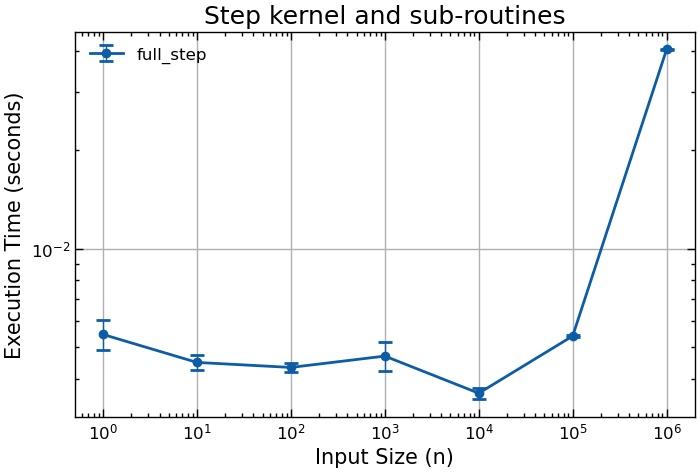

In [10]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

## Measure python overhead

In [9]:
from src.numba_target import my_act_parallel_loop, my_parallel_loop
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

from src.utils import update_langevin_time

benchmark = {}

num_repeats = 10  # Number of repetitions for statistics
num_executions = 100  # Number of executions in each timeit call
num_trajs_max_exp = 6

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs))
    sim = ComplexLangevinSimulation(config)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    # Function to profile
    def get_args():
        sim.cldyn_kernel_bridge.get_current_params()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()

    def update_noise():
        my_act_parallel_loop(
            sim.noise_kernel,
            sim.alive,
            sim.trajs,
            sim.eta, 
            sim.noise_factor,
            sim.rng
            )
        if use_cuda: cuda.synchronize() # just testing

    def update_noise_python():
        sim.update_noise(*sim.cldyn_kernel_args[sim.noise_kernel].values())

    def update_drift_python():
        my_act_parallel_loop(
            sim.drift_kernel,
            sim.alive,
            sim.trajs, 
            sim.phi0, 
            sim.dS, 
            sim.dS_norm, 
            sim.sigma, 
            sim.interaction
            )
        if use_cuda: cuda.synchronize() # just testing
    
    def update_drift(): 
        sim.update_drift(*sim.cldyn_kernel_args[sim.drift_kernel].values())

        # # if use_cuda: cuda.synchronize() # just testing

    def update_field_python():
        sim.update_field(*sim.cldyn_kernel_args[sim.evolve_kernel].values())

    def update_field():
        my_act_parallel_loop(
            sim.evolve_kernel,
            sim.alive,
            sim.trajs, 
            sim.phi0, 
            sim.phi1, 
            sim.dS, 
            sim.eta, 
            sim.ada, 
            sim.dt, 
            sim.adims,
            sim.langevin_time,
            )
        
        # my_act_parallel_loop(
        #     update_langevin_time, 
        #     sim.alive,
        #     sim.trajs,
        #     sim.langevin_time,
        #     sim.ada,
        #     sim.dt
        # )
        if use_cuda: cuda.synchronize() # just testing


    if use_cuda: cuda.synchronize() # just testing
    # def swap():
    #     sim.swap()
        
    # def set_apative_stepsize():
    #     sim.set_apative_stepsize()
    
    # def step():
    #     sim.step()

    functions_to_test = [update_noise, update_noise_python, update_drift, update_drift_python, update_field, update_field_python]

    # warmup
    for func in functions_to_test:
        func()

    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 


100%|██████████| 7/7 [00:25<00:00,  3.59s/it]


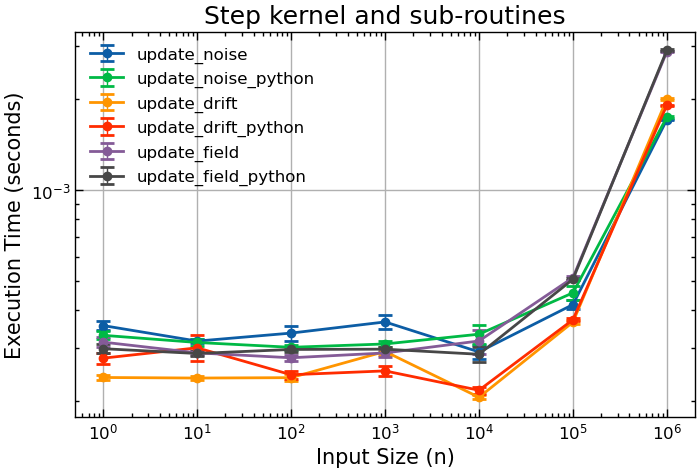

In [10]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

### Testing cuda.synchronize()

In [1]:

# imports
# Add cle_fun to PYTHON_PATH
import sys, os, json
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda


Using single precision
Using C^1
Using Numba


In [2]:
num_repeats = 5  # Number of repetitions for statistics
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 5

# Trajectories range from 1 to 10^5

# Define a function for benchmarking
config = Config(trajs=int(100), sigma = 1+1j, dt = 1e-3, history_grid_size = 1e-3, steps = int(1e4))
sim = ComplexLangevinSimulation(config)
sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=sim.dt, maximal_lt=100)

if use_cuda:
    gpu_handler = GPU_handler(sim)
    gpu_handler.to_device()

In [3]:

import cupy as cp
import tqdm
min_lt = 0
max_lt = 10
num_trajs_blur = 100
results = [np.zeros(sim.steps, dtype=scal.SCAL_TYPE) for idx in range(num_trajs_blur)]
times = [np.zeros(sim.steps, dtype=scal.SCAL_TYPE) for idx in range(num_trajs_blur)]

# while cp.min(cp.asarray(sim.langevin_time)[cp.asarray(sim.alive)]) < max_lt:
    # min_lt = cp.min(cp.asarray(sim.langevin_time)[cp.asarray(sim.alive)])
for idx in tqdm.tqdm(range(sim.steps)):
    # min_lt = np.min(sim.langevin_time[sim.alive])
    sim.step()
    sim.kill_trajs()
    for name, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()
        for k in range(num_trajs_blur):
            if tr.equilibrated_trajs[k]: 
                results[k][idx] = tr.result[k]
                times[k][idx] = tr.meas_time[k]

print("Done")


100%|██████████| 10000/10000 [00:13<00:00, 765.29it/s]

Done


In [4]:
sim.finish()

In [5]:
sim.trackers["1_moment"].history_meas_times

array([1.00000024e-03, 2.00000048e-03, 4.00000095e-03, ...,
       9.99740702e+00, 9.99841207e+00, 9.99940999e+00])

/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


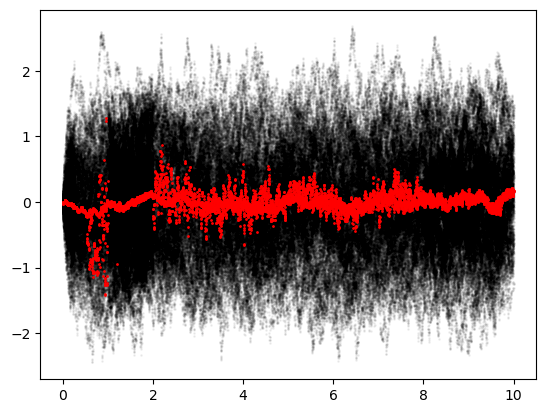

In [6]:
for k in range(100):
    plt.scatter(times[k], results[k], s = 1, color="black", alpha = 0.05)
plt.scatter(sim.trackers["1_moment"].history_meas_times,sim.trackers["1_moment"].history_result, s = 1, color = "red")

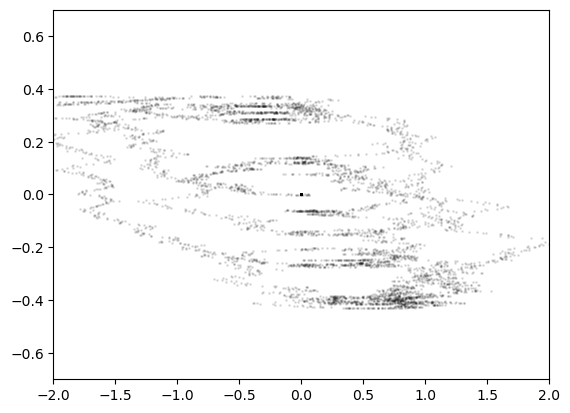

In [35]:
k = 4
plt.xlim(-2, 2)
plt.ylim(-0.7, 0.7)
plt.scatter(results[k].real, results[k].imag, s = 1, color="black", alpha = 0.1)

In [39]:
for k in range(10):
    results[k]= results[k][results[k]!=0]

/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/matplotlib/collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


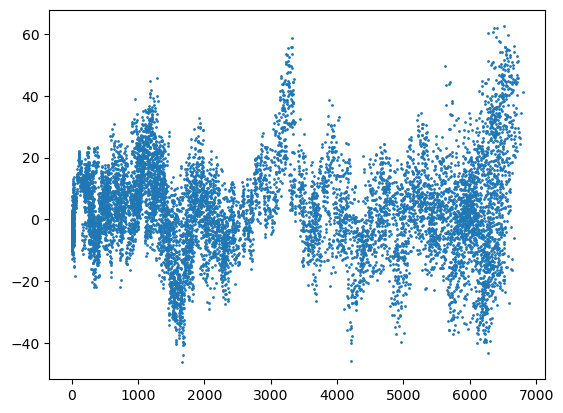

In [22]:
import matplotlib.pyplot as plt
plt.scatter(sim.trackers["1_moment"].history_meas_times,sim.trackers["1_moment"].history_result, s = 1)

In [1]:

# imports
# Add cle_fun to PYTHON_PATH
import sys, os, json
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "cuda"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop,
    my_parallel_loop,
    myjit
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda


Using single precision
Using C^1
Using CUDA


In [2]:
# Parameters
arr_size = int(2)
min_lt = 1
max_lt = 1
dt = (max_lt - min_lt) / arr_size
dt = 0.001

# Generate measurement times and complex results
meas_time = np.random.uniform(size=arr_size,low = min_lt, high = max_lt, )
result =np.random.random(arr_size) + 1j * np.random.random(arr_size)

meas_time = cp.asarray(cuda.to_device(meas_time))
result = cp.asarray(cuda.to_device(result))

NameError: name 'cp' is not defined

In [89]:
meas_time

array([1., 1.])

In [91]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt


# Create bins for binning
bins = cp.arange(0, 5 + dt, dt)
bin_indices = cp.digitize(meas_time, bins)  # Assign each time to a bin

# Compute real and imaginary parts in each bin
real_part = cp.bincount(bin_indices, weights=result.real)
imag_part = cp.bincount(bin_indices, weights=result.imag)
bin_counts = cp.bincount(bin_indices)

bin_centers = (bins[:-1] + bins[1:]) / 2


In [93]:
nonzero_mask = bin_counts > 0
real_part_binned = real_part[nonzero_mask] / bin_counts[nonzero_mask]
bin_indices

array([1001, 1001])

In [ ]:

# Mask to filter non-zero bin counts
nonzero_mask = bin_counts > 0

# Compute bin centers
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calculate binned real and imaginary parts
real_part_binned = real_part[nonzero_mask] / bin_counts[nonzero_mask]
imag_part_binned = imag_part[nonzero_mask] / bin_counts[nonzero_mask]

# # Plot results as step plot for binned data
plt.figure(figsize=(8, 5))
plt.step(bin_centers[nonzero_mask].get(), real_part_binned.get(), label="Rebinned Real Part", where='mid', color="blue")
plt.scatter(meas_time.get(), result.get().real, label="Raw Real Part", color="red", alpha=0.6)
plt.xlabel("Measurement Time")
plt.ylabel("Real Part of Result")
plt.legend()
plt.grid(True)
plt.title("Comparison of Raw and Rebinned Data (Step Plot)")
plt.show()

In [194]:
history_counter = np.zeros(int(1e5), dtype=scal.IDX_TYPE)
history_result = np.zeros(int(1e5), dtype=scal.SCAL_TYPE)
history_meas_times = np.zeros(int(1e5), dtype=scal.SCAL_TYPE_REAL)

In [195]:
import cupy as cp
my_parallel_loop(non_thread_safe_add, arr_size, history_counter, history_result, 
                 history_meas_times, meas_time, result, dt)

In [196]:
mask = history_counter>1
history_result_rebinned = history_result[mask] / history_counter[mask]
history_meas_times_rebinned = history_meas_times[mask] / history_counter[mask]